# Analyse des résolutions et DPI par corpus

Pour chacun des trois corpus (**iconographie**, **manuscrits/plans**, **presse**), et à l'intérieur de chaque corpus pour chaque `corpus_code`, on trace des **boîtes à moustaches** de :

- la **résolution X** (`mix_imageWidth`, en pixels) ;
- la **résolution Y** (`mix_imageHeight`, en pixels) ;
- les **DPI** (`mix_xSamplingFrequency`).

Source : `results/corpus/corpus_*_20260619.csv.gz`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Racine du dépôt (le notebook est dans scripts/img/)
ROOT = Path.cwd()
while not (ROOT / "results").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CORPUS_DIR = ROOT / "results" / "corpus"

CORPUS = {
    "Iconographie": CORPUS_DIR / "corpus_iconographie_20260619.csv.gz",
    "Manuscrits / Plans": CORPUS_DIR / "corpus_manuscrits_plans_20260619.csv.gz",
    "Presse": CORPUS_DIR / "corpus_presse_20260619.csv.gz",
}

# Colonnes étudiées : libellé affiché -> nom de colonne
METRIQUES = {
    "Résolution X (px)": "mix_imageWidth",
    "Résolution Y (px)": "mix_imageHeight",
    "DPI": "mix_xSamplingFrequency",
}

In [2]:
def charger(path: Path) -> pd.DataFrame:
    """Charge un corpus et convertit les colonnes métriques en numérique."""
    df = pd.read_csv(path, low_memory=False)
    for col in METRIQUES.values():
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


donnees = {nom: charger(path) for nom, path in CORPUS.items()}

# Aperçu : nombre de fichiers par corpus_code
for nom, df in donnees.items():
    print(f"{nom} — {len(df)} fichiers")
    print(df["corpus_code"].value_counts().sort_index().to_string())
    print()

Iconographie — 185 fichiers
corpus_code
AMR_AFF    37
AMR_DEL    37
MED_AFF    37
MED_CP     37
MED_IMA    37

Manuscrits / Plans — 111 fichiers
corpus_code
MED_MON    37
MED_MS     37
MED_PLA    37

Presse — 296 fichiers
corpus_code
PRA_AVE    37
PRA_BDR    37
PRA_CRT    37
PRA_CTG    37
PRA_ERT    37
PRA_IND    37
PRA_JRX    37
PRA_RTG    37



In [3]:
def boites_par_code(nom: str, df: pd.DataFrame):
    """Trace, pour un corpus, une boîte à moustaches par corpus_code
    et par métrique (résolution X, résolution Y, DPI)."""
    ordre = sorted(df["corpus_code"].dropna().unique())
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{nom} — résolutions et DPI par corpus_code", fontsize=15, fontweight="bold")

    for ax, (libelle, col) in zip(axes, METRIQUES.items()):
        sns.boxplot(data=df, x="corpus_code", y=col, order=ordre, ax=ax)
        sns.stripplot(
            data=df, x="corpus_code", y=col, order=ordre, ax=ax,
            color=".25", size=3, alpha=0.4,
        )
        ax.set_title(libelle)
        ax.set_xlabel("")
        ax.set_ylabel(libelle)
        ax.tick_params(axis="x", rotation=45)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")

    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

## Iconographie

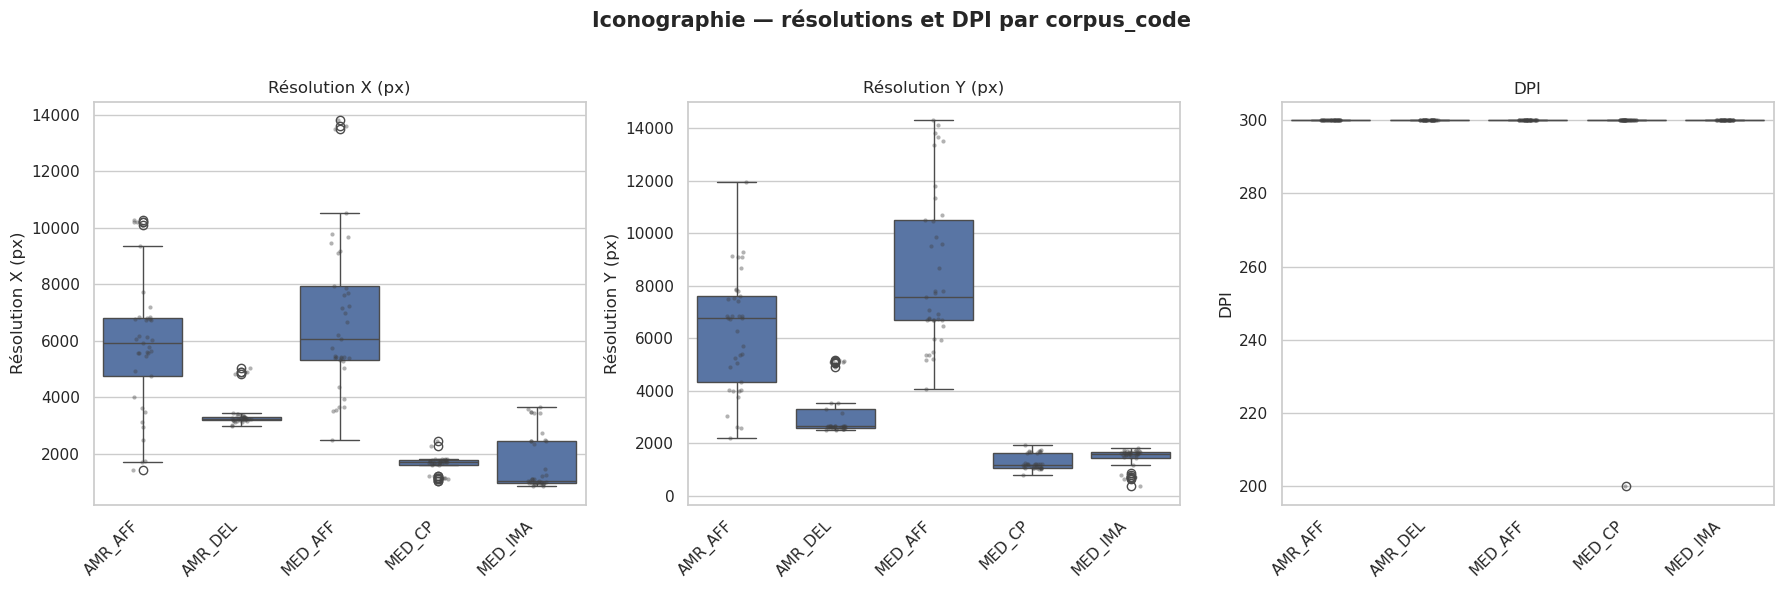

In [4]:
boites_par_code("Iconographie", donnees["Iconographie"])

## Manuscrits / Plans

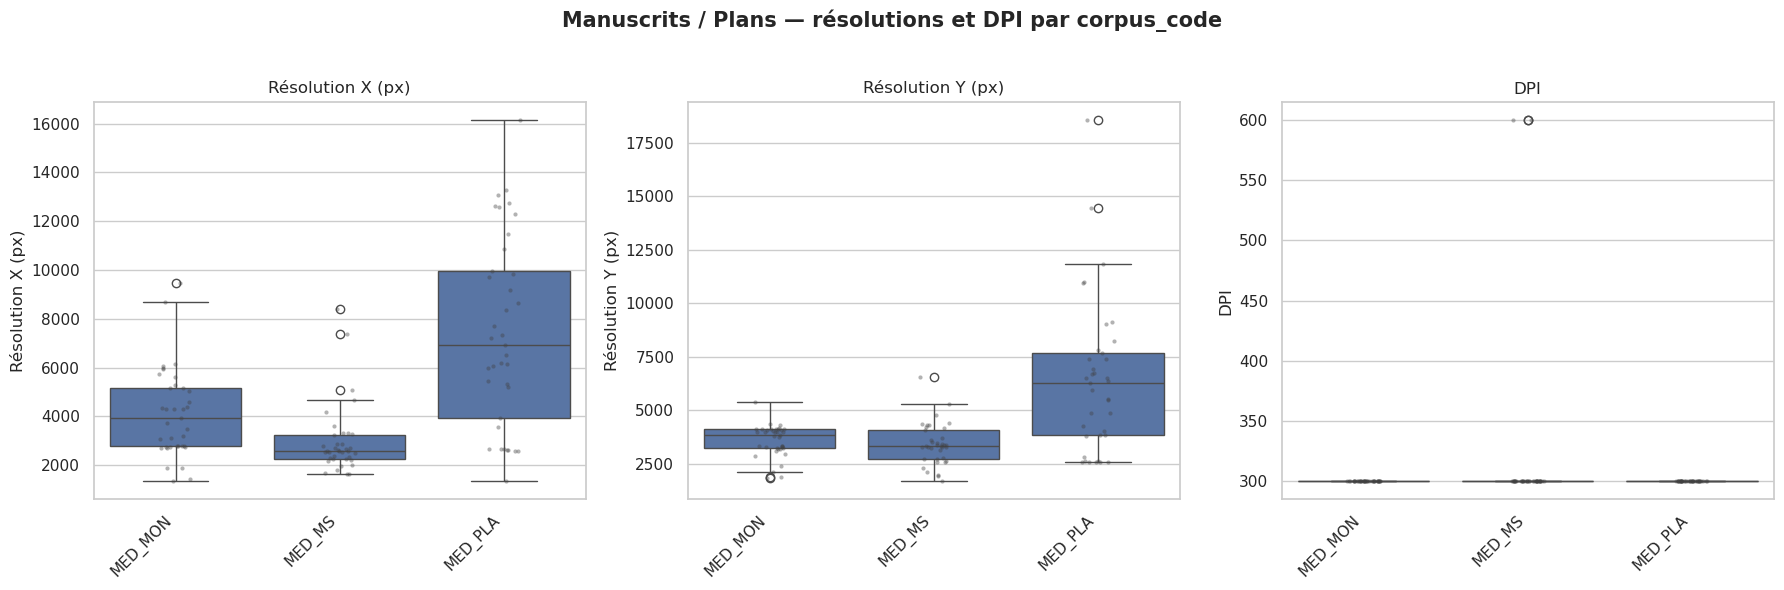

In [5]:
boites_par_code("Manuscrits / Plans", donnees["Manuscrits / Plans"])

## Presse

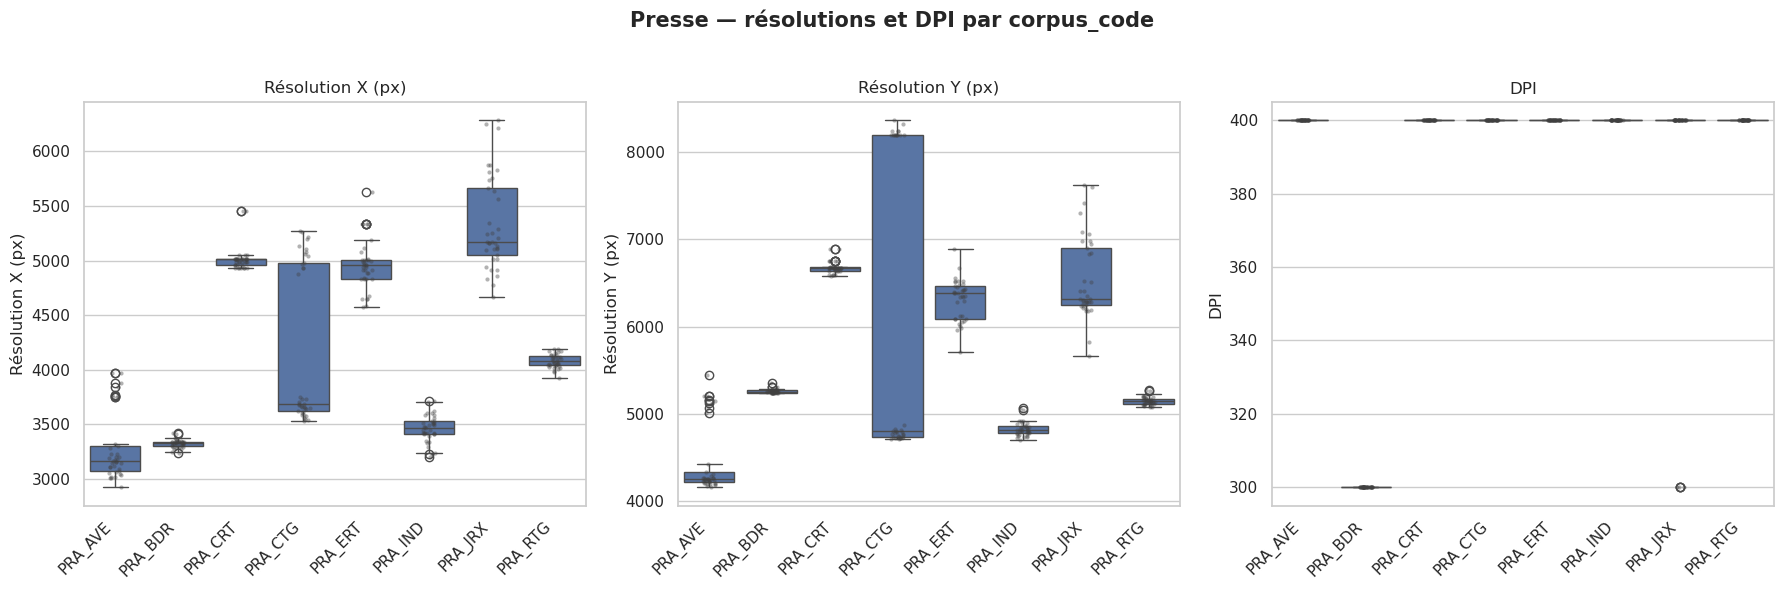

In [6]:
boites_par_code("Presse", donnees["Presse"])

# Réduction de résolution proposée

On définit **trois niveaux de réduction**, calibrés sur l'analyse ci-dessus, avec un **plancher de 2000 px** sur la résolution X.

| Corpus | Niveau | Facteur `f` |
|---|---|---|
| Manuscrits / Plans | **haut** | 0,80 |
| Iconographie | **moyen** | 0,65 |
| Presse | **bas** | 0,50 |

**Formule** appliquée à chaque image (largeur `w`, hauteur `h`, DPI `d`) :

```
s  = min(1, max(f, 2000 / w))   # facteur d'échelle effectif
w' = round(w · s)               # largeur réduite
h' = round(h · s)               # hauteur (ratio préservé)
d' = round(d · s)               # DPI réduit d'autant
```

- `max(f, 2000/w)` → la résolution X ne descend **jamais** sous 2000 px ;
- `min(1, …)` → **pas d'agrandissement** des images déjà plus petites que 2000 px.

In [7]:
# Niveaux de réduction : corpus -> (niveau, facteur f)
NIVEAUX = {
    "Iconographie": ("moyen", 0.65),
    "Manuscrits / Plans": ("haut", 0.80),
    "Presse": ("bas", 0.50),
}
PLANCHER_X = 2000  # la résolution X ne descend jamais sous ce seuil (px)

In [8]:
def reduire(df: pd.DataFrame, f: float, plancher: int = PLANCHER_X) -> pd.DataFrame:
    """Renvoie une copie de df enrichie du facteur d'échelle `s` et des
    colonnes après réduction : x_ap, y_ap, dpi_ap.

    s = min(1, max(f, plancher / w))
      - max(f, plancher/w) : X ne descend jamais sous le plancher ;
      - min(1, ...)        : pas d'agrandissement des images déjà petites.
    """
    out = df.copy()
    w = out["mix_imageWidth"]
    h = out["mix_imageHeight"]
    d = out["mix_xSamplingFrequency"]
    s = np.minimum(1.0, np.maximum(f, plancher / w))
    out["s"] = s
    out["x_ap"] = (w * s).round()
    out["y_ap"] = (h * s).round()
    out["dpi_ap"] = (d * s).round()
    return out


# Métriques avant/après : libellé -> (colonne avant, colonne après)
METRIQUES_AA = {
    "Résolution X (px)": ("mix_imageWidth", "x_ap"),
    "Résolution Y (px)": ("mix_imageHeight", "y_ap"),
    "DPI": ("mix_xSamplingFrequency", "dpi_ap"),
}


def avant_apres(nom: str, df: pd.DataFrame):
    """Trace, par corpus_code, les boîtes à moustaches avant/après réduction
    pour la résolution X, la résolution Y et les DPI."""
    niveau, f = NIVEAUX[nom]
    red = reduire(df, f)
    ordre = sorted(red["corpus_code"].dropna().unique())
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f"{nom} — avant / après réduction (niveau {niveau}, f={f}, plancher {PLANCHER_X} px)",
        fontsize=15, fontweight="bold",
    )
    for ax, (libelle, (c_av, c_ap)) in zip(axes, METRIQUES_AA.items()):
        long = pd.concat([
            red[["corpus_code", c_av]].rename(columns={c_av: "valeur"}).assign(état="avant"),
            red[["corpus_code", c_ap]].rename(columns={c_ap: "valeur"}).assign(état="après"),
        ])
        sns.boxplot(
            data=long, x="corpus_code", y="valeur", hue="état",
            order=ordre, hue_order=["avant", "après"], ax=ax,
        )
        if libelle.startswith("Résolution"):
            ax.axhline(PLANCHER_X, color="red", ls="--", lw=1)
        ax.set_title(libelle)
        ax.set_xlabel("")
        ax.set_ylabel(libelle)
        ax.tick_params(axis="x", rotation=45)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")
        ax.legend(title="", fontsize=8)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

## Iconographie — avant / après

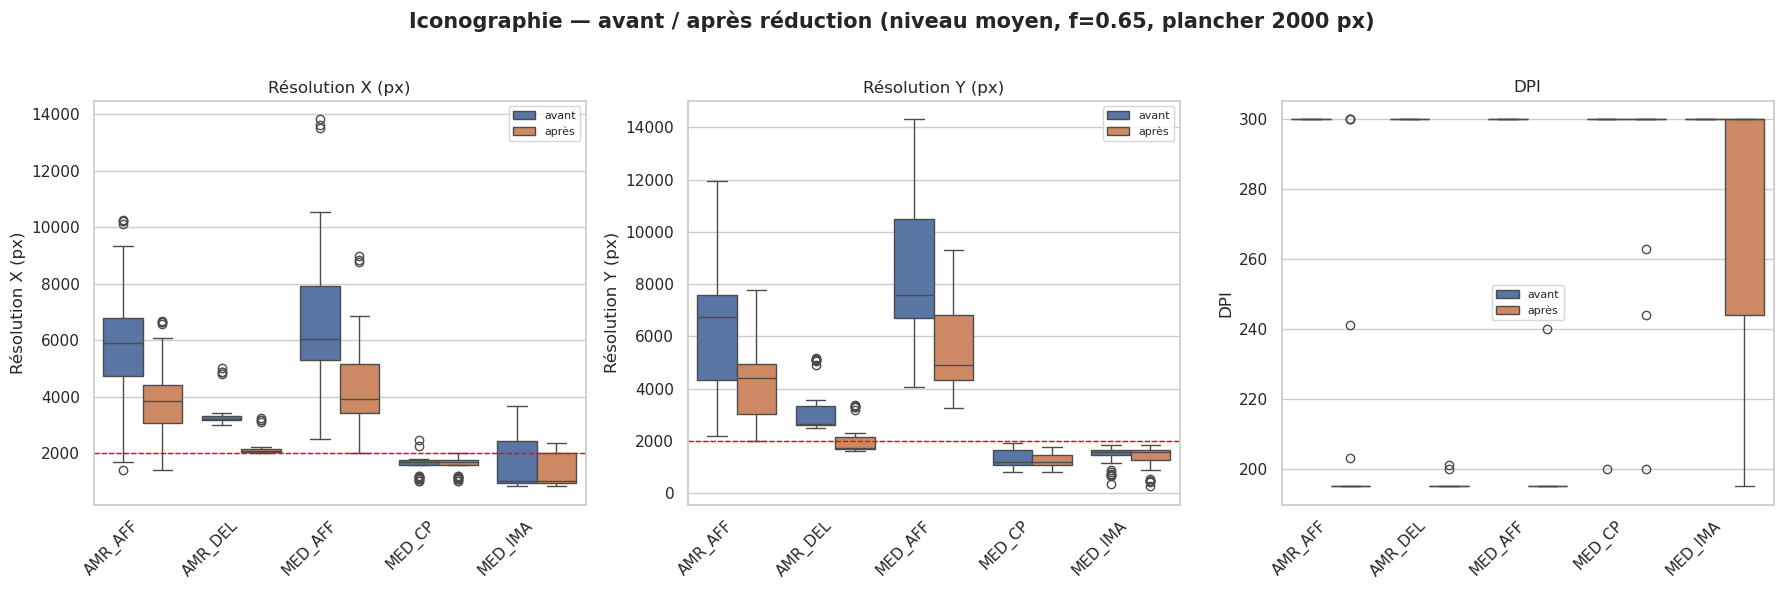

In [9]:
avant_apres("Iconographie", donnees["Iconographie"])

## Manuscrits / Plans — avant / après

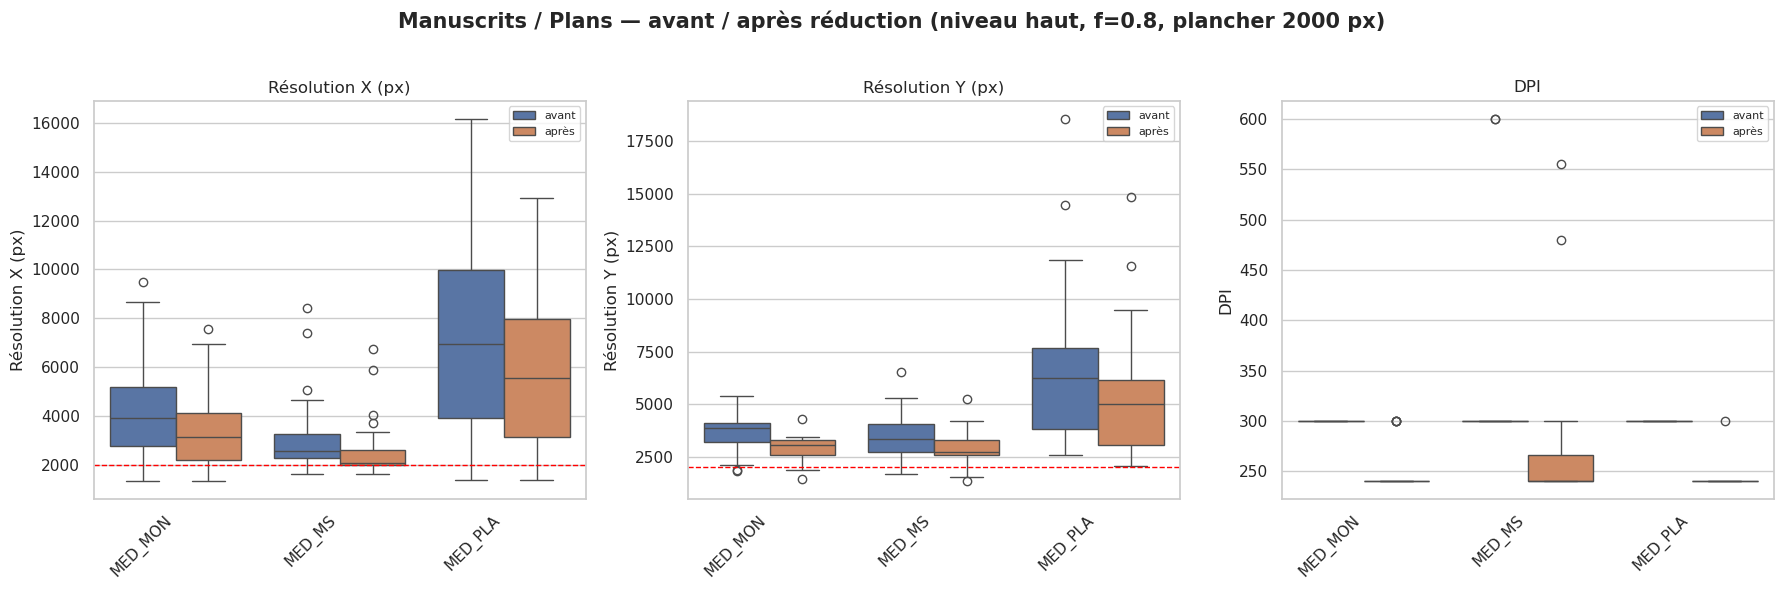

In [10]:
avant_apres("Manuscrits / Plans", donnees["Manuscrits / Plans"])

## Presse — avant / après

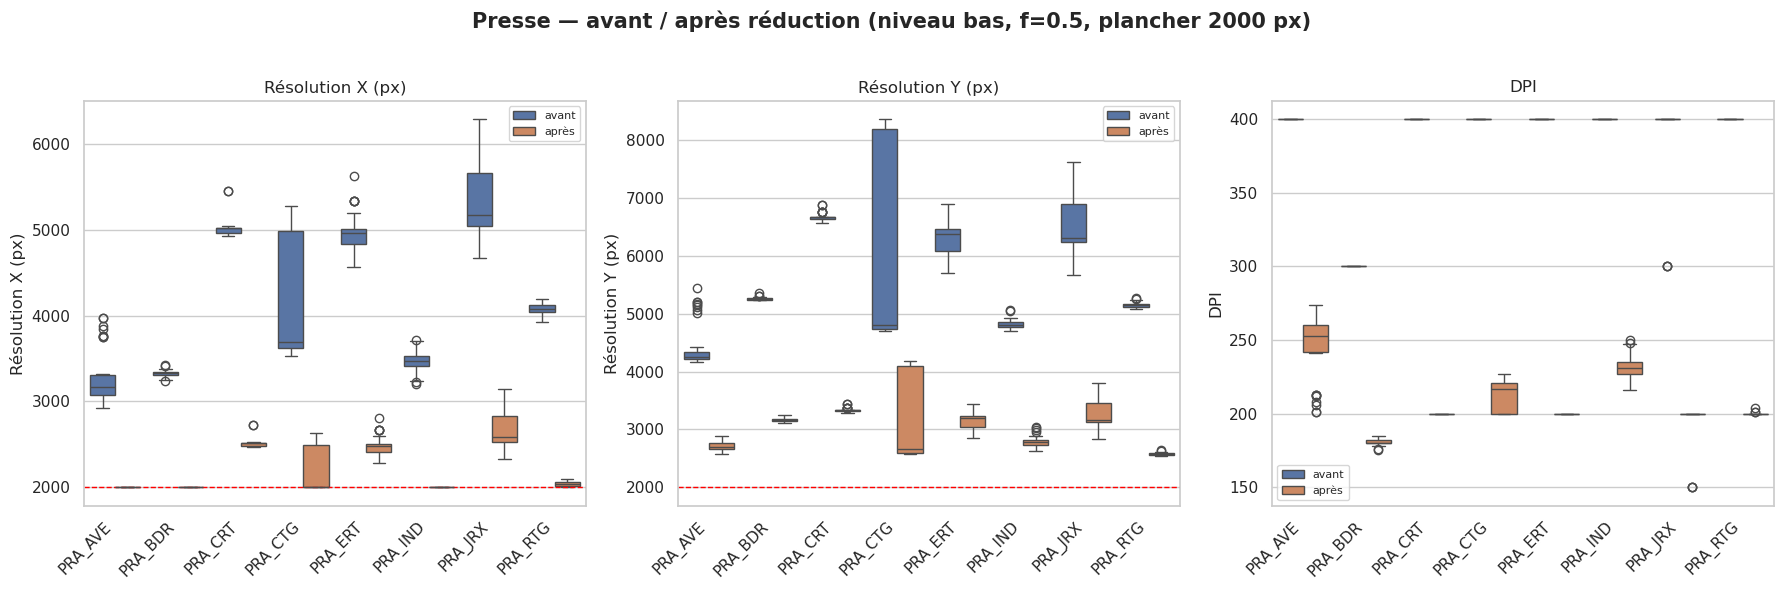

In [11]:
avant_apres("Presse", donnees["Presse"])

## Récapitulatif de l'impact

In [12]:
lignes = []
for nom, df in donnees.items():
    niveau, f = NIVEAUX[nom]
    red = reduire(df, f)
    w = red["mix_imageWidth"]
    px_av = (red["mix_imageWidth"] * red["mix_imageHeight"]).sum()
    px_ap = (red["x_ap"] * red["y_ap"]).sum()
    lignes.append({
        "corpus": nom,
        "niveau": niveau,
        "f": f,
        "X méd. avant": int(w.median()),
        "X méd. après": int(red["x_ap"].median()),
        "DPI méd. après": int(red["dpi_ap"].median()),
        "volume px restant %": round(px_ap / px_av * 100),
        "réduites": int((red["s"] < 0.999).sum()),
        "plancher 2000": int(((w * f < PLANCHER_X) & (red["s"] < 0.999)).sum()),
        "inchangées": int((red["s"] >= 0.999).sum()),
    })

recap = pd.DataFrame(lignes).set_index("corpus")
recap

,niveau,f,X méd. avant,X méd. après,DPI méd. après,volume px restant %,réduites,plancher 2000,inchangées
corpus,,,,,,,,,
Iconographie,moyen,0.65,3231,2100,195,44,122,13,63
Manuscrits / Plans,haut,0.80,3472,2778,240,65,101,9,10
Presse,bas,0.50,4054,2027,200,28,296,137,0
